# Part C
Create an auto-explainer for the NFA to DFA conversion. The preamble here will be the starter NFA, and each step carries out one additional state made in the corresponding DFA. The course notes have an in-depth example of what I would expect the output to be, although it does not have to be exactly the same.

My approach will be to first remove all e-transitions from the NFA. 

In [144]:
from automata.fa.nfa import NFA
from automata.fa.dfa import DFA


# NFA which matches strings beginning with "a", ending with "a", and
# containing no consecutive "b"s
my_nfa = NFA(
    states={"q0", "q1", "q2", "q3"},
    input_symbols={"a", "b"},
    transitions={
        "q0": {"a": {"q1"}},
        "q1": {"a": {"q1"}, "": {"q2"}},
        "q2": {"b": {"q0"}},
        "q3": {}
    },
    initial_state="q0",
    final_states={"q1"},
)

C:\Users\matthew.wanta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pygraphviz\agraph.py:1403: RuntimeWarning: Warning: pos attribute for edge (q2,q0) doesn't have 3n+1 points

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


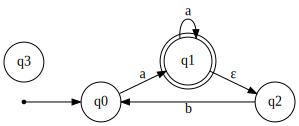

In [145]:
my_nfa.show_diagram()

In [146]:
import pandas as pd

def make_table(target_fa) -> pd.DataFrame:
    initial_state = target_fa.initial_state
    final_states = target_fa.final_states

    table = {}

    for from_state, to_state, symbol in target_fa.iter_transitions():
        # Prepare nice string for from_state
        if isinstance(from_state, frozenset):
            from_state_str = str(set(from_state))
        else:
            from_state_str = str(from_state)

        if from_state in final_states:
            from_state_str = "*" + from_state_str
        if from_state == initial_state:
            from_state_str = "→" + from_state_str

        # Prepare nice string for to_state
        if isinstance(to_state, frozenset):
            to_state_str = str(set(to_state))
        else:
            to_state_str = str(to_state)

        if to_state in final_states:
            to_state_str = "*" + to_state_str

        # Prepare nice symbol
        if symbol == "":
            symbol = "ε"

        from_state_dict = table.setdefault(from_state_str, dict())
        from_state_dict.setdefault(symbol, set()).add(to_state_str)

    # Reformat table for singleton sets
    for symbol_dict in table.values():
        for symbol in symbol_dict:
            if len(symbol_dict[symbol]) == 1:
                symbol_dict[symbol] = symbol_dict[symbol].pop()


    df = pd.DataFrame.from_dict(table).fillna("∅").T
    return df.reindex(sorted(df.columns), axis=1)

In [147]:
make_table(my_nfa)

,a,b,ε
→q0,*q1,∅,∅
*q1,*q1,∅,q2
q2,∅,q0,∅


## Worked Example
For ease of use, I'm going to copy the NFA from the lesson 7 page.

In [148]:
from automata.fa.nfa import NFA

# NFA which matches strings beginning with "a", ending with "a", and
# containing no consecutive "b"s
example_nfa = NFA(
    states={"q1", "q2", "q3", "q4", "q5"},
    input_symbols={"a", "b"},
    transitions={
        "q1": {"a": {"q2"}, "": {"q3"}},
        "q2": {"a": {"q3", "q4"}, "b": {"q2"}},
        "q3": {"a": {"q5"}, "b": {"q1", "q2", "q5"}},
        "q4": {"b": {"q3", "q5"}, "": {"q3"}},
        "q5": {}
    },
    initial_state="q1",
    final_states={"q5"},
)

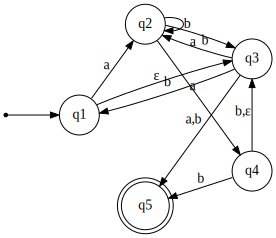

In [149]:
example_nfa.show_diagram(layout_method="circo", path="part_c_out/output.png")

The `automata` library already has a built-in e-transition remover. However, proving it step by step is a bit different.

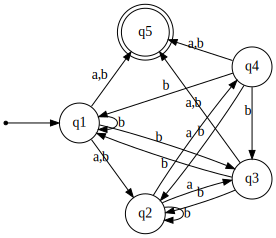

In [150]:
example_nfa.eliminate_lambda().show_diagram(layout_method="circo")

First compute the ${\epsilon}$ closure of each state and display in a tabular format.

In [151]:
import pandas as pd

def make_e_closure_table(target_fa) -> pd.DataFrame:
    initial_state = target_fa.initial_state
    final_states = target_fa.final_states
    all_states = target_fa.states

    table = {state: {"ε":{state}} for state in all_states}

    for from_state, to_state, symbol in target_fa.iter_transitions():
        # Prepare nice string for from_state
        if isinstance(from_state, frozenset):
            from_state_str = str(set(from_state))
        else:
            from_state_str = str(from_state)


        # Prepare nice string for to_state
        if isinstance(to_state, frozenset):
            to_state_str = str(set(to_state))
        else:
            to_state_str = str(to_state)

        if to_state in final_states:
            to_state_str = "*" + to_state_str

        # Prepare nice symbol
        if symbol == "":
            symbol = "ε"

            from_state_dict = table.setdefault(from_state_str, dict())
            from_state_dict.setdefault(symbol, set()).add(to_state_str)

    # Convert to DataFrame
    df = pd.DataFrame([(state, set(data['ε'])) for state, data in table.items()], 
                  columns=['State', 'ε-Transitions'])

    # Sort by state
    return df.sort_values(by='State').reset_index(drop=True)

Boom, now we have an e-closure table.

In [152]:
e_closure = make_e_closure_table(example_nfa)
e_closure

,State,ε-Transitions
0,q1,"{q1, q3}"
1,q2,{q2}
2,q3,{q3}
3,q4,"{q3, q4}"
4,q5,{q5}


I'm going to try a visualization experiment; bear with me.

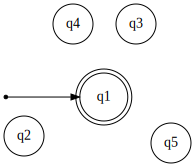

In [153]:
# NFA which matches strings beginning with "a", ending with "a", and
# containing no consecutive "b"s
working_nfa = NFA(
    states={"q1", "q2", "q3", "q4", "q5"},
    input_symbols={"a", "b"},
    transitions={
        "q1": {},
        "q2": {},
        "q3": {},
        "q4": {},
        "q5": {}
    },
    initial_state="q1",
    final_states={"q1"},
)

working_nfa.show_diagram(layout_method="circo")

That's our blank set of states. First, we must compute the e-closure of each state in M.

In [154]:
def get_e_closure(state, table):
    return table.loc[table['State'] == state, 'ε-Transitions'].values[0]

In [155]:
closure = get_e_closure("q1", e_closure)
print(closure)

{'q1', 'q3'}


In [156]:
M = {}
for char in example_nfa.input_symbols: 
    M[char] = set()
    for state in closure:
        # adjacent states
        # if that transition exists on that state
        if char in example_nfa.transitions[state]: 
            # add all transitions 
            M[char]  = M[char].union(set(example_nfa.transitions[state][char]))

M
        

{'a': {'q2', 'q5'}, 'b': {'q1', 'q2', 'q5'}}

In [157]:
E = M.copy()
for char, states in M.items():
    for state in M[char]:
        E[char] = E[char].union(get_e_closure(state, e_closure))
print(E)

{'a': {'q5', 'q2'}, 'b': {'q1', 'q2', 'q5', 'q3'}}


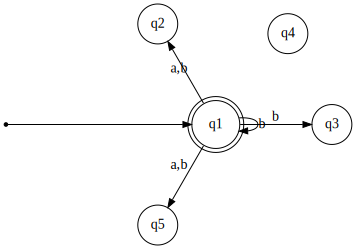

In [158]:
working_nfa = NFA(
    states={"q1", "q2", "q3", "q4", "q5"},
    input_symbols={"a", "b"},
    transitions={
        "q1": E,
        "q2": {},
        "q3": {},
        "q4": {},
        "q5": {}
    },
    initial_state="q1",
    final_states={"q1"},
)

working_nfa.show_diagram(layout_method="circo")

Yay! I got one full step down. Now to operationalize this process.

In [159]:
def remove_e_transitions_from_state(state, nfa, table):
    closure = get_e_closure(state, table)

    M = {}
    for char in nfa.input_symbols: 
        M[char] = set()
        for _state in closure:
            # if that transition exists on that state
            if char in nfa.transitions[_state]: 
                # add all transitions 
                M[char]  = M[char].union(set(nfa.transitions[_state][char]))

    E = M.copy()
    for char, states in M.items():
        for _state in states:
            E[char] = E[char].union(get_e_closure(_state, e_closure))

    return E

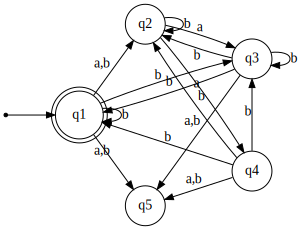

In [160]:
transitions = {state: {} for state in example_nfa.states}
sorted_states = sorted(example_nfa.states, key=lambda x: int(x[1]))

for state in sorted_states:
    transitions[state] = remove_e_transitions_from_state(
        state, example_nfa, e_closure
        )

    working_nfa = NFA(
        states={"q1", "q2", "q3", "q4", "q5"},
        input_symbols={"a", "b"},
        transitions=transitions,
        initial_state="q1",
        final_states={"q1"},
    )
    working_nfa.show_diagram(layout_method="circo", path=f"part_c_out/step_{state}.png")


working_nfa.show_diagram(layout_method="circo")


## Converting a NFA without ${\epsilon}$-transitions to a DFA

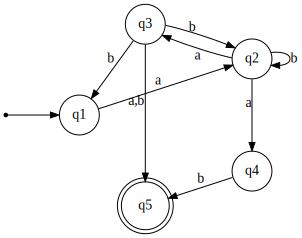

In [161]:
working_nfa = NFA(
    states={"q1", "q2", "q3", "q4", "q5"},
    input_symbols={"a", "b"},
    transitions={
        "q1": {"a": {"q2"}},
        "q2": {"a": {"q3", "q4"}, "b": {"q2"}},
        "q3": {"a": {"q5"}, "b": {"q1", "q2", "q5"}},
        "q4": {"b": {"q5"}},
        "q5": {}
    },
    initial_state="q1",
    final_states={"q5"},
)

working_nfa.show_diagram(layout_method="circo")

In [162]:
def merge_frozendicts(*dicts, input):
    merged = {}
    
    for d in dicts:
        for key in input:
            if key in d:
                merged[key] = merged.get(key, frozenset()).union(d[key])
            else:
                merged[key] = merged.get(key, frozenset())
    
    return merged

In [163]:
import pprint

dfa_table = {}
working_states = [frozenset([working_nfa.initial_state])]
# entries of the form {states: {symbols: states}}


for states in working_states:
    transitions = merge_frozendicts(*[working_nfa.transitions[state] for state in states],
                                    input=working_nfa.input_symbols)
    dfa_table[states] = transitions

    for incremental_subset in transitions.values():
        if incremental_subset not in working_states:
            working_states.append(incremental_subset)

dfa_table[frozenset()] = {x: {} for x in working_nfa.input_symbols}
final_states = {states for states in working_states if states.intersection(working_nfa.final_states)}

dfa_table = {' '.join(key): value for key, value in dfa_table.items()}
for key, value in dfa_table.items():
    dfa_table[key] = {k: set(v) for k, v in value.items()}
pprint.pprint(dfa_table)

{'': {'a': set(), 'b': set()},
 'q1': {'a': {'q2'}, 'b': set()},
 'q2': {'a': {'q3', 'q4'}, 'b': {'q2'}},
 'q3 q4': {'a': {'q5'}, 'b': {'q5', 'q1', 'q2'}},
 'q3 q4 q2': {'a': {'q5', 'q3', 'q4'}, 'b': {'q5', 'q1', 'q2'}},
 'q5': {'a': set(), 'b': set()},
 'q5 q1 q2': {'a': {'q3', 'q4', 'q2'}, 'b': {'q2'}},
 'q5 q3 q4': {'a': {'q5'}, 'b': {'q5', 'q1', 'q2'}}}


In [164]:
def merge_frozendicts(*dicts, input_symbols):
    merged = {symbol: frozenset() for symbol in input_symbols}
    for d in dicts:
        for key, value in d.items():
            if key in merged:
                merged[key] = merged[key].union(value)
            else:
                merged[key] = value
    return merged

In [188]:
def show_dfa_table(dfa_table, working_nfa):
    symbols = sorted(working_nfa.input_symbols)
    df = pd.DataFrame([(state, *[set(data[symbol] if data[symbol] != frozenset() else "∅") for symbol in symbols]) 
                       for state, data in dfa_table.items()], 
                  columns=['DFA State', *symbols])
    return df

In [197]:

dfa_table = {}
working_states = [frozenset([working_nfa.initial_state])]
# entries of the form {states: {symbols: states}}

for states in working_states:
    print(show_dfa_table(dfa_table, working_nfa))
    transitions = merge_frozendicts(*[working_nfa.transitions[state] for state in states], input_symbols=working_nfa.input_symbols)
    dfa_table[states] = transitions

    for incremental_subset in transitions.values():
        if incremental_subset not in working_states:
            working_states.append(incremental_subset)


# Ensure all input symbols are represented in the DFA table
for states in dfa_table:
    for symbol in working_nfa.input_symbols:
        if symbol not in dfa_table[states]:
            dfa_table[states][symbol] = frozenset()

# Convert frozensets to sets for readability
dfa_table = {frozenset(key) if len(key) != 1 else key: 
             {k: set(v) if len(v) != 1 else v for k, v in value.items()} 
             for key, value in dfa_table.items()}

# Convert states to strings for the final DFA
final_dfa_table = {' '.join(state): {symbol: ' '.join(subset) for symbol, subset in transitions.items()} for state, transitions in dfa_table.items()}

show_dfa_table(final_dfa_table, working_nfa)

Empty DataFrame
Columns: [DFA State, a, b]
Index: []
  DFA State     a    b
0      (q1)  {q2}  {∅}
  DFA State         a     b
0      (q1)      {q2}   {∅}
1      (q2)  {q3, q4}  {q2}
  DFA State         a     b
0      (q1)      {q2}   {∅}
1      (q2)  {q3, q4}  {q2}
2        ()       {∅}   {∅}
  DFA State         a             b
0      (q1)      {q2}           {∅}
1      (q2)  {q3, q4}          {q2}
2        ()       {∅}           {∅}
3  (q3, q4)      {q5}  {q5, q1, q2}
  DFA State         a             b
0      (q1)      {q2}           {∅}
1      (q2)  {q3, q4}          {q2}
2        ()       {∅}           {∅}
3  (q3, q4)      {q5}  {q5, q1, q2}
4      (q5)       {∅}           {∅}
      DFA State             a             b
0          (q1)          {q2}           {∅}
1          (q2)      {q3, q4}          {q2}
2            ()           {∅}           {∅}
3      (q3, q4)          {q5}  {q5, q1, q2}
4          (q5)           {∅}           {∅}
5  (q5, q1, q2)  {q3, q4, q2}          {q2}
 

,DFA State,a,b
0,q1,"{2, q}",{}
1,q2,"{q, 3, 4, }","{2, q}"
2,,{},{}
3,q3 q4,"{q, 5}","{1, q, , 2, 5}"
4,q5,{},{}
5,q5 q1 q2,"{3, q, , 2, 4}","{2, q}"
6,q3 q4 q2,"{3, q, , 4, 5}","{1, q, , 2, 5}"
7,q5 q3 q4,"{q, 5}","{1, q, , 2, 5}"


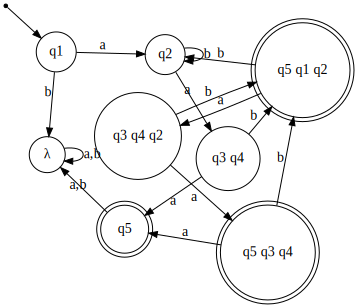

In [ ]:
# Define the final DFA
final_dfa = DFA(
    states=set(final_dfa_table.keys()),
    input_symbols=working_nfa.input_symbols,
    transitions=final_dfa_table,
    initial_state=' '.join(frozenset([working_nfa.initial_state])),
    final_states={' '.join(state) for state in working_states if state.intersection(working_nfa.final_states)}
)

final_dfa.show_diagram(layout_method="fdp")